In [1]:
pip install opencv-python matplotlib numpy


Note: you may need to restart the kernel to use updated packages.


In [2]:
clear


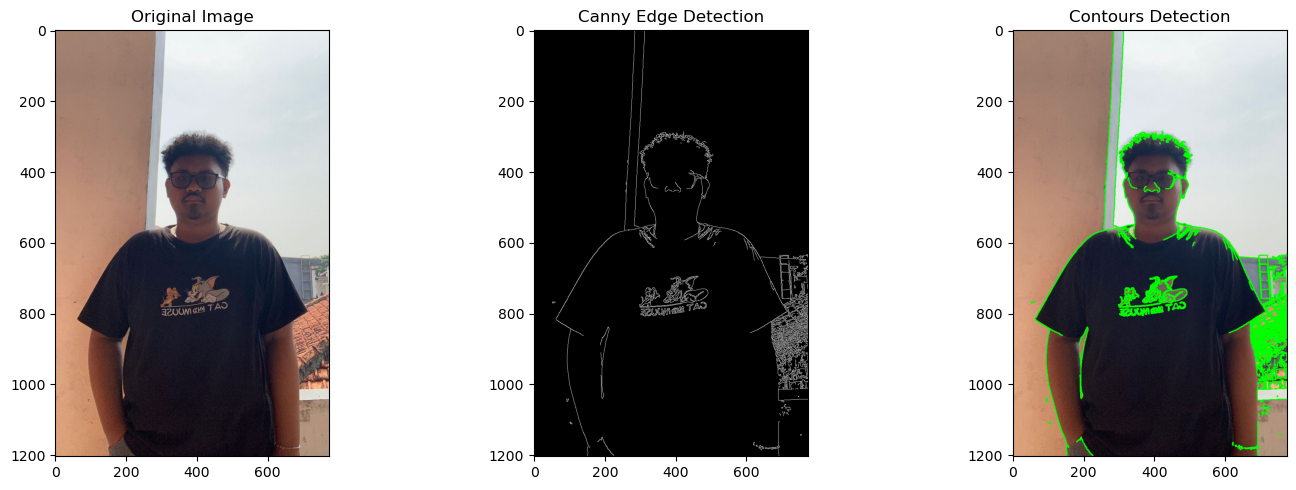

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- BAGIAN A: DETEKSI TEPI POLA OBJEK ---
# Load Gambar
image_path = 'diri.jpeg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Proses Konversi ke Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny Edge Detection (Ubah nilai 100, 200 jika garis tepi kurang pas)
edges = cv2.Canny(gray, 100, 200)

# Contours Detection
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2) # Garis kontur warna hijau

# Menampilkan Hasil
plt.figure(figsize=(15, 5))

# Plot 1: Original Image
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('on') 

# Plot 2: Canny Edge Detection
plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('on')

# Plot 3: Contours Detection
plt.subplot(1, 3, 3)
plt.imshow(img_contours)
plt.title('Contours Detection')
plt.axis('on')

plt.tight_layout()
plt.show()


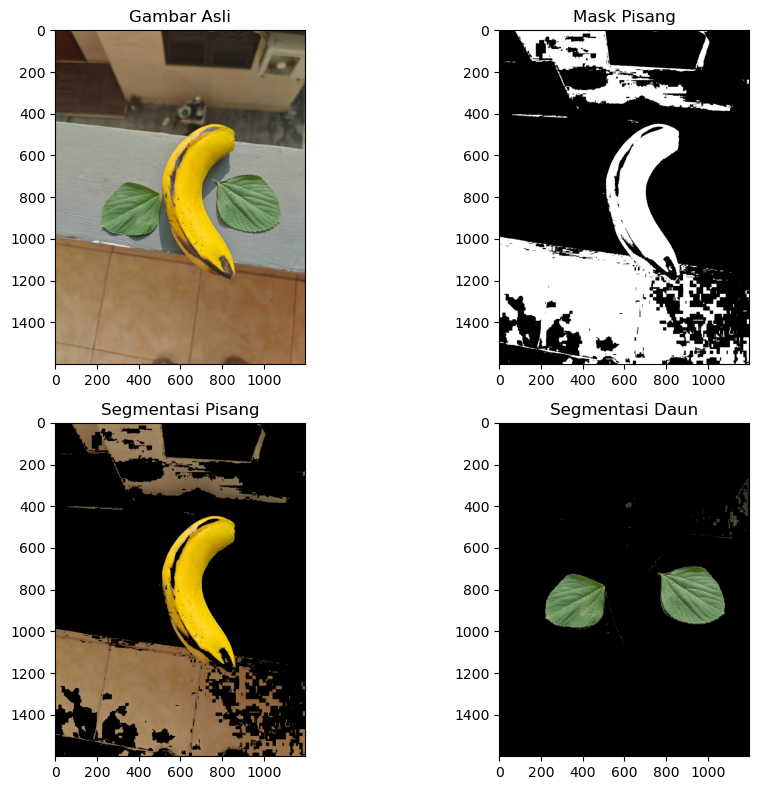

In [4]:
# --- BAGIAN B: DETEKSI BUAH DAN DAUN ---
# Load Gambar Pisang
image_pisang_path = 'pisang.jpeg'
img_pisang = cv2.imread(image_pisang_path)
img_pisang_rgb = cv2.cvtColor(img_pisang, cv2.COLOR_BGR2RGB)

# Konversi ke format HSV untuk memudahkan masking warna
hsv_pisang = cv2.cvtColor(img_pisang, cv2.COLOR_BGR2HSV)

# 1. Masking & Segmentasi untuk Buah Pisang (Warna Kuning)
# Catatan: Jika pisangmu masih hijau/mentah, kamu harus sedikit mengubah range nilai HSV ini
lower_yellow = np.array([15, 100, 100])
upper_yellow = np.array([35, 255, 255])
mask_pisang = cv2.inRange(hsv_pisang, lower_yellow, upper_yellow)
segmentasi_pisang = cv2.bitwise_and(img_pisang_rgb, img_pisang_rgb, mask=mask_pisang)

# 2. Masking & Segmentasi untuk Daun (Warna Hijau)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
mask_daun = cv2.inRange(hsv_pisang, lower_green, upper_green)
segmentasi_daun = cv2.bitwise_and(img_pisang_rgb, img_pisang_rgb, mask=mask_daun)

# Menampilkan Hasil (Format 2x2 sesuai contoh soal)
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_pisang_rgb)
plt.title('Gambar Asli')
plt.axis('on')

plt.subplot(2, 2, 2)
plt.imshow(mask_pisang, cmap='gray')
plt.title('Mask Pisang')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(segmentasi_pisang)
plt.title('Segmentasi Pisang')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(segmentasi_daun)
plt.title('Segmentasi Daun')
plt.axis('on')

plt.tight_layout()
plt.show()

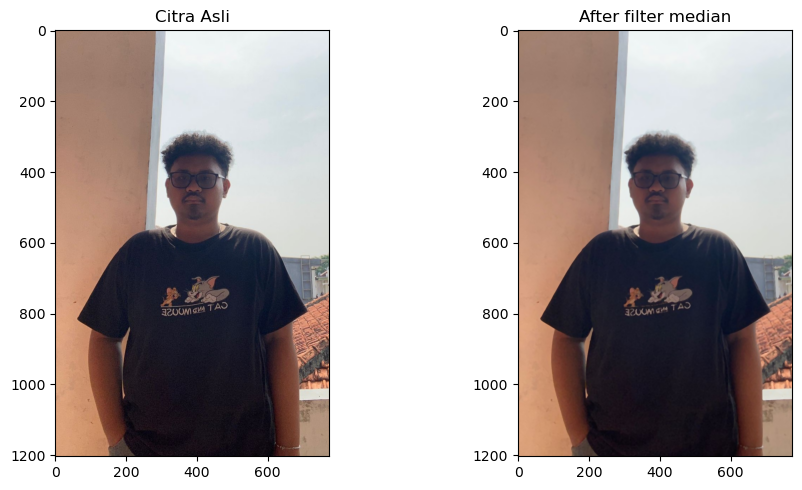

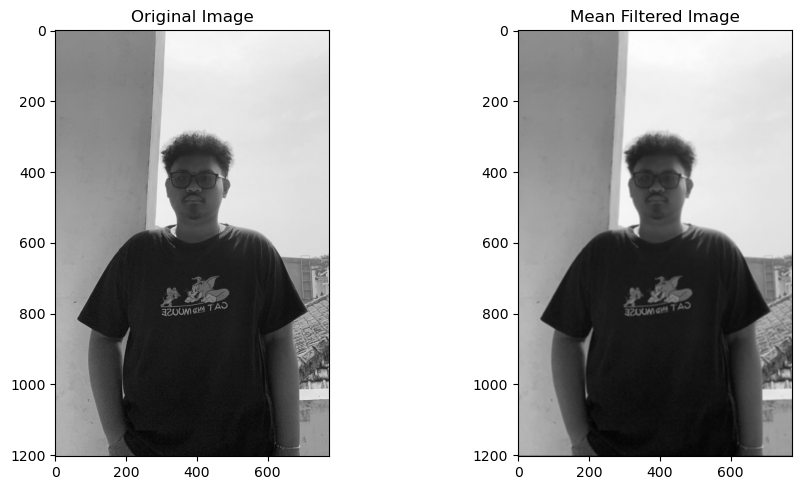

In [5]:
# Load gambar asli
image_path = 'diri.jpeg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================================
# 1. MEDIAN FILTERING (Menggunakan OpenCV)
# ==========================================
# Menggunakan kernel ukuran 5x5
median_filtered = cv2.medianBlur(img_rgb, 5)

# ==========================================
# 2. MEAN FILTERING (Perhitungan Manual)
# ==========================================
# Menggunakan gambar Grayscale (sesuai contoh di soal)
k_size = 5 # Ukuran kernel 5x5
pad = k_size // 2

# Menambahkan padding (batas tepi) agar kernel bisa membaca pinggiran gambar
img_padded = np.pad(img_gray, pad, mode='constant', constant_values=0)
mean_filtered = np.zeros_like(img_gray)

# Proses perhitungan rata-rata (mean) secara manual piksel demi piksel
tinggi, lebar = img_gray.shape
for i in range(tinggi):
    for j in range(lebar):
        # Mengambil area matriks sebesar ukuran kernel (5x5)
        window = img_padded[i:i+k_size, j:j+k_size]
        # Menghitung rata-rata dan memasukkannya ke gambar baru
        mean_filtered[i, j] = np.sum(window) // (k_size * k_size)

# ==========================================
# MENAMPILKAN HASIL FILTERING
# ==========================================
# Menampilkan Median Filter (Gambar Berwarna)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(median_filtered)
plt.title('After filter median')
plt.axis('on')
plt.tight_layout()
plt.show()

# Menampilkan Mean Filter (Gambar Grayscale)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filtered Image')
plt.axis('on')
plt.tight_layout()
plt.show()

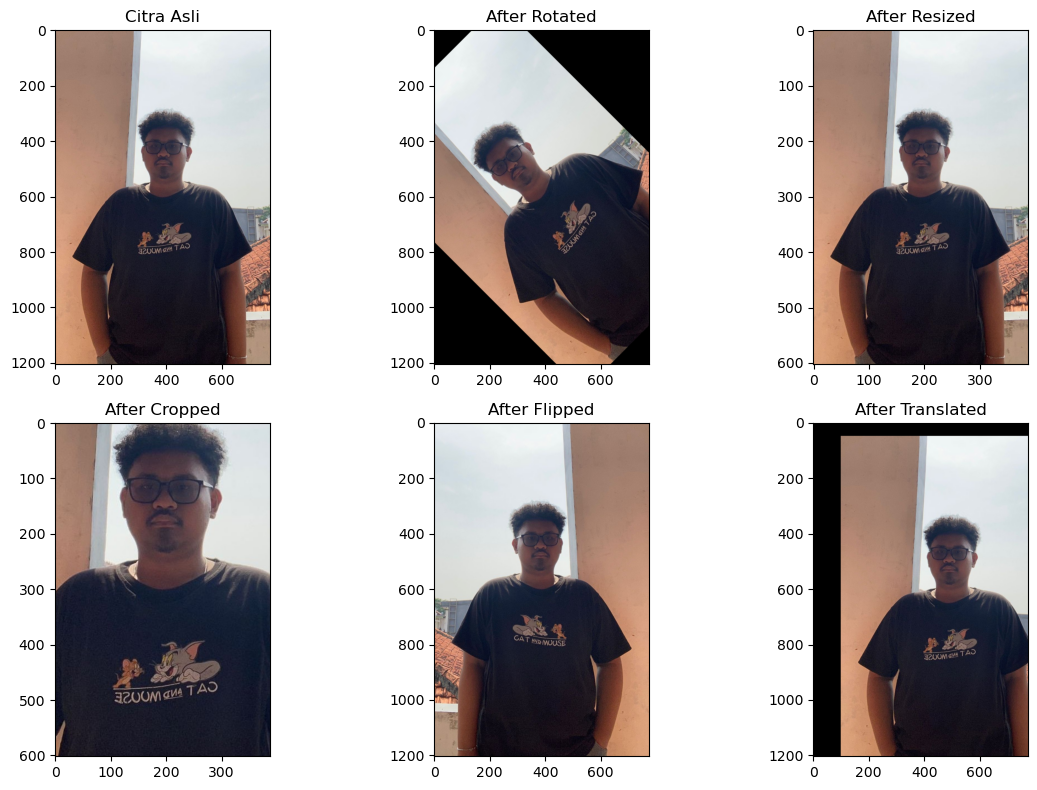

In [6]:

# Load gambar asli
image_path = 'diri.jpeg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

# 1. Citra Asli
citra_asli = img_rgb.copy()

# 2. Rotated (Diputar 45 derajat)
center = (w // 2, h // 2)
matrix_rotasi = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img_rgb, matrix_rotasi, (w, h))

# 3. Resized (Ubah ukuran menjadi setengah dari aslinya)
resized = cv2.resize(img_rgb, (w // 2, h // 2))

# 4. Cropped (Dipotong mengambil bagian tengah gambar)
# Kamu bisa menyesuaikan angka pembaginya jika bagian tubuhmu yang terpotong kurang pas
cropped = img_rgb[h//4 : 3*h//4, w//4 : 3*w//4]

# 5. Flipped (Dibalik secara horizontal / seperti cermin)
flipped = cv2.flip(img_rgb, 1) 

# 6. Translated (Digeser posisinya: X geser 100 piksel, Y geser 50 piksel)
matrix_translasi = np.float32([[1, 0, 100], [0, 1, 50]])
translated = cv2.warpAffine(img_rgb, matrix_translasi, (w, h))

# ==========================================
# MENAMPILKAN HASIL GEOMETRI CITRA
# ==========================================
plt.figure(figsize=(12, 8))

# Plot 1: Citra Asli
plt.subplot(2, 3, 1)
plt.imshow(citra_asli)
plt.title('Citra Asli')
plt.axis('on')

# Plot 2: Rotated
plt.subplot(2, 3, 2)
plt.imshow(rotated)
plt.title('After Rotated')
plt.axis('on')

# Plot 3: Resized
plt.subplot(2, 3, 3)
plt.imshow(resized)
plt.title('After Resized')
plt.axis('on')

# Plot 4: Cropped
plt.subplot(2, 3, 4)
plt.imshow(cropped)
plt.title('After Cropped')
plt.axis('on')

# Plot 5: Flipped
plt.subplot(2, 3, 5)
plt.imshow(flipped)
plt.title('After Flipped')
plt.axis('on')

# Plot 6: Translated
plt.subplot(2, 3, 6)
plt.imshow(translated)
plt.title('After Translated')
plt.axis('on')

plt.tight_layout()
plt.show()